# 70%-sequence-identity clustered dual split — peak design

**Goal.** Replace the *random* 70/15/15 train/val/test split (owned by
`../dataset_pipeline/make_dual_split.py` → `dual_splits.csv`) with a split where whole
**70%-sequence-identity clusters** are kept together, so no test/val protein has a ≥70%-identity
homolog in training. Fluorescent proteins are dominated by a few large mutational lineages
(avGFP, DsRed, …), so a random split leaks near-identical variants across the train/test boundary
and the reported peak-MAE is optimistic. A homology-aware split measures generalization to
*unseen* sequence families.

**What this notebook does** (it does **not** touch any existing file, weights, or code):
1. Cluster all curated sequences at **70% identity** (BLOSUM62 global alignment, identity =
   identical residues / shorter-sequence length; single-linkage / connected components).
2. Build a **cluster-aware coordinated dual split** that keeps the exact structure of the current
   pipeline — two splits with disjoint val sets and the invariants `S_test ⊆ O_train`,
   `O_test ⊆ S_train` — but with every split boundary falling **between** clusters.
3. Quantify the homology leakage of the random split vs. this one and visualize both.

**Outputs (new files only):** `seqid70_clusters.csv`, `dual_splits_seqid70.csv` in the curated
data dir. Consumed by `surrogate_oracle_peak_seqid70.ipynb`.

> Run order: this notebook → `surrogate_oracle_peak_seqid70.ipynb`.


## 0. Setup + load curated sequences / peaks

In [1]:
import os, csv, json, time, numpy as np
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC=True
except Exception:
    HAVE_APC=False
import matplotlib.pyplot as plt
class _C:
    def __getattr__(self,k): return getattr(apc,k) if HAVE_APC else {"aegean":"#2b6c8f","amber":"#f6a200","rose":"#c5474b","seaweed":"#3b8a6e","gray":"#888888","wish":"#5088c5","aster":"#7a5ea8","lime":"#97cd3f","dragon":"#c85152"}.get(k,"#333333")
apc_c=_C()

CUR="../dataset_pipeline/data/peak/curated"     # curated dataset (same source the random split uses)
rows=list(csv.DictReader(open(os.path.join(CUR,"peaks_assignments.csv")))); N=len(rows)
names=[r["name"] for r in rows]
peaks=np.load(os.path.join(CUR,"peaks.npy")).astype(np.float32)   # (N,2) [ex_max, em_max] nm
# sequences.fasta headers are ">{index}|..."; map back to curated row order
seqs=[None]*N; h=None
for line in open(os.path.join(CUR,"sequences.fasta")):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqs[h]=line
assert all(s is not None for s in seqs), "missing sequences"
L=np.array([len(s) for s in seqs])
print(f"N={N} curated proteins | seq len {L.min()}-{L.max()} | ex_max {peaks[:,0].min():.0f}-{peaks[:,0].max():.0f} nm | em_max {peaks[:,1].min():.0f}-{peaks[:,1].max():.0f} nm")


N=758 curated proteins | seq len 134-582 | ex_max 343-611 nm | em_max 414-684 nm


## 1. Cluster at 70% sequence identity

Pairwise **global** alignment (BLOSUM62, gap open −11 / extend −1 — Biopython `PairwiseAligner`
defaults for protein). Identity is defined as *identical aligned residues / length of the shorter
sequence*; two proteins are linked when identity ≥ 0.70. Clusters are the connected components of
that graph (single-linkage), the same transitive notion CD-HIT/MMseqs2 use — so no protein in one
cluster has a ≥70% match to any protein in another.

A cheap **5-mer containment prefilter** skips pairs that cannot reach 70% before doing the
(expensive) alignment; this makes the full N² sweep run in well under a minute for N≈760.

In [2]:
from Bio.Align import PairwiseAligner, substitution_matrices
aligner=PairwiseAligner()
aligner.substitution_matrix=substitution_matrices.load("BLOSUM62")
aligner.open_gap_score=-11; aligner.extend_gap_score=-1; aligner.mode="global"

THR=0.70            # identity threshold for an edge
K=5                 # k-mer size for the prefilter
PRE=0.30            # min 5-mer containment to bother aligning a pair
kmers=[frozenset(s[i:i+K] for i in range(len(s)-K+1)) for s in seqs]

parent=list(range(N))
def find(x):
    while parent[x]!=x: parent[x]=parent[parent[x]]; x=parent[x]
    return x
def union(a,b):
    ra,rb=find(a),find(b)
    if ra!=rb: parent[ra]=rb

t0=time.time(); n_aln=0; n_edge=0
for i in range(N):
    ki=kmers[i]
    for j in range(i+1,N):
        mn=min(len(ki),len(kmers[j]))
        if mn==0 or len(ki & kmers[j])/mn < PRE:   # prefilter
            continue
        n_aln+=1
        al=aligner.align(seqs[i],seqs[j])[0]
        idfrac=al.counts().identities/min(L[i],L[j])
        if idfrac>=THR:
            union(i,j); n_edge+=1
print(f"clustering done in {time.time()-t0:.0f}s | aligned {n_aln:,} candidate pairs | {n_edge:,} edges >=70% identity")

# connected components -> contiguous cluster ids ordered by descending size
comp={}
for i in range(N): comp.setdefault(find(i),[]).append(i)
comps=sorted(comp.values(), key=len, reverse=True)
clab=np.empty(N,dtype=int)
for cid,members in enumerate(comps):
    for i in members: clab[i]=cid
sizes=np.bincount(clab)
print(f"{len(comps)} clusters | largest {sizes.max()} ({100*sizes.max()/N:.0f}% of N) | "
      f"singletons {(sizes==1).sum()} | top10 sizes {sizes[:10].tolist()}")


clustering done in 20s | aligned 45,874 candidate pairs | 45,248 edges >=70% identity
57 clusters | largest 273 (36% of N) | singletons 23 | top10 sizes [273, 113, 100, 83, 17, 16, 13, 10, 9, 8]


### 1a. Cluster-size distribution

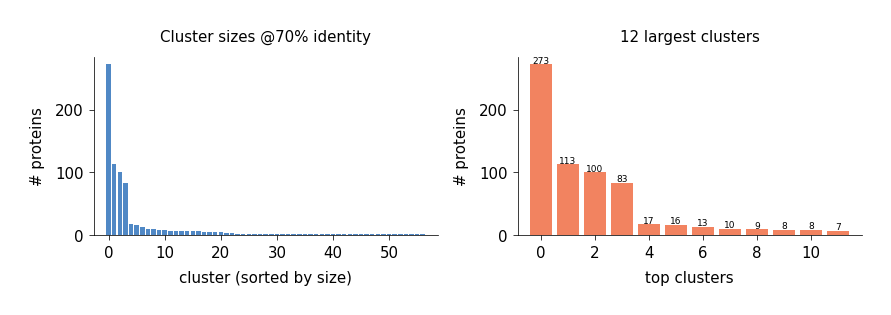

wrote ../dataset_pipeline/data/peak/curated/seqid70_clusters.csv


In [3]:
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].bar(np.arange(len(sizes)),sizes,color=apc_c.aegean)
ax[0].set_xlabel("cluster (sorted by size)"); ax[0].set_ylabel("# proteins"); ax[0].set_title("Cluster sizes @70% identity")
ax[1].bar(np.arange(min(12,len(sizes))),sizes[:12],color=apc_c.amber)
for i,v in enumerate(sizes[:12]): ax[1].text(i,v+2,str(v),ha="center",fontsize=9)
ax[1].set_xlabel("top clusters"); ax[1].set_ylabel("# proteins"); ax[1].set_title("12 largest clusters")
plt.tight_layout(); plt.show()

# persist cluster labels (new file)
with open(os.path.join(CUR,"seqid70_clusters.csv"),"w",newline="") as fh:
    w=csv.writer(fh); w.writerow(["index","name","cluster_id","cluster_size"])
    for i in range(N): w.writerow([i,names[i],int(clab[i]),int(sizes[clab[i]])])
print("wrote",os.path.join(CUR,"seqid70_clusters.csv"))


## 2. Cluster-aware coordinated dual split

Same coordinated structure as `make_dual_split.py`, but assigning **whole clusters** instead of
individual proteins:

* **Surrogate (S)** split: carve ~15% test and ~15% val as whole clusters; the rest is S-train.
* **Oracle (O)** split: carve O-test / O-val as whole clusters **from the S-train pool only**;
  everything else is O-train.

This preserves the invariants the design workflow relies on — `S_test ⊆ O_train`,
`O_test ⊆ S_train`, and disjoint val sets — so the oracle still judges surrogate-designed
sequences it never trained on, **and** every train/val/test boundary now falls between clusters.

The allocator is a deterministic greedy best-fit (clusters sorted by descending size; each cluster
goes to the carve-role with the largest remaining deficit if it fits within a tolerance, else to
train). Because FP clusters are lumpy (one lineage is ~36% of the data), realized test/val sizes
land near — not exactly on — 15%.

In [4]:
TOL=20   # a cluster may overshoot a carve-role's remaining deficit by up to TOL and still be placed there
def alloc(pool, targets):
    """Assign whole clusters within `pool` (index array) to carve-roles to approach `targets`
    (dict role->count). Leftover clusters -> 'train'. Deterministic: size desc, id tie-break."""
    pool=np.asarray(pool)
    cl=np.unique(clab[pool])
    csize={c:int((clab[pool]==c).sum()) for c in cl}
    deficit=dict(targets); role_of={}
    for c in sorted(cl, key=lambda c:(-csize[c], c)):
        s=csize[c]; best=None
        for r in targets:
            if deficit[r]>0 and s<=deficit[r]+TOL and (best is None or deficit[r]>deficit[best]):
                best=r
        if best is None: role_of[c]="train"
        else: role_of[c]=best; deficit[best]-=s
    role=np.array(["train"]*N,dtype=object)
    for c in cl: role[pool[clab[pool]==c]]=role_of[c]
    return role

n_te=int(round(0.15*N)); n_va=int(round(0.15*N))
allidx=np.arange(N)
Srole=alloc(allidx, {"test":n_te,"val":n_va})                 # surrogate carves from everything
s_train_pool=np.where(Srole=="train")[0]
Orole=np.array(["train"]*N,dtype=object)                       # oracle: everyone train ...
Ocarve=alloc(s_train_pool, {"test":n_te,"val":n_va})          # ... except test/val carved from S-train
for i in s_train_pool: Orole[i]=Ocarve[i]

def cnt(a): return {b:int((a==b).sum()) for b in ("train","val","test")}
print(f"target test/val = {n_te} each ({100*n_te/N:.0f}%)")
print("surrogate (S):", cnt(Srole), "->", {k:f'{100*v/N:.0f}%' for k,v in cnt(Srole).items()})
print("oracle    (O):", cnt(Orole), "->", {k:f'{100*v/N:.0f}%' for k,v in cnt(Orole).items()})


target test/val = 114 each (15%)
surrogate (S): {'train': 512, 'val': 117, 'test': 129} -> {'train': '68%', 'val': '15%', 'test': '17%'}
oracle    (O): {'train': 530, 'val': 114, 'test': 114} -> {'train': '70%', 'val': '15%', 'test': '15%'}


### 2a. Verify invariants and cluster-disjointness

In [5]:
Sr=Srole.astype(str); Or=Orole.astype(str)
assert np.all(Or[Sr=="test"]=="train"), "S_test must be subset of O_train"
assert np.all(Sr[Or=="test"]=="train"), "O_test must be subset of S_train"
assert np.sum((Sr=="val")&(Or=="val"))==0, "val sets must be disjoint"
def cross(role):
    return {f"{a}|{b}": len(set(clab[role==a]) & set(clab[role==b]))
            for a,b in [("train","test"),("train","val"),("val","test")]}
print("dual invariants OK: S_test in O_train, O_test in S_train, val disjoint")
print("surrogate shared clusters across splits:", cross(Sr), "(all 0 = no homology leakage)")
print("oracle    shared clusters across splits:", cross(Or), "(all 0 = no homology leakage)")

with open(os.path.join(CUR,"dual_splits_seqid70.csv"),"w",newline="") as fh:
    w=csv.writer(fh); w.writerow(["index","name","surrogate_role","oracle_role"])
    for i in range(N): w.writerow([i,names[i],Sr[i],Or[i]])
print("wrote",os.path.join(CUR,"dual_splits_seqid70.csv"))


dual invariants OK: S_test in O_train, O_test in S_train, val disjoint
surrogate shared clusters across splits: {'train|test': 0, 'train|val': 0, 'val|test': 0} (all 0 = no homology leakage)
oracle    shared clusters across splits: {'train|test': 0, 'train|val': 0, 'val|test': 0} (all 0 = no homology leakage)
wrote ../dataset_pipeline/data/peak/curated/dual_splits_seqid70.csv


## 3. Homology leakage: random split vs. 70%-identity split

For each split we count how many **test** (and val) proteins share a 70%-identity cluster with any
**training** protein — i.e. how many held-out proteins have a near-duplicate the model already saw.
By construction the clustered split is 0%; the random split is expected to be near-total because a
few lineages dominate the data.

In [6]:
rand=sorted(csv.DictReader(open(os.path.join(CUR,"dual_splits.csv"))), key=lambda r:int(r["index"]))
RSr=np.array([r["surrogate_role"] for r in rand]); ROr=np.array([r["oracle_role"] for r in rand])
def leak(role):
    tr=set(clab[role=="train"]); out={}
    for s in ("val","test"):
        idx=np.where(role==s)[0]
        nl=int(sum(clab[i] in tr for i in idx)); out[s]=(len(idx),nl,round(100*nl/max(len(idx),1),1))
    return out
print(f"{'split':28s} {'val (n, leaked, %)':>26} {'test (n, leaked, %)':>26}")
for lab,role in [("RANDOM surrogate",RSr),("RANDOM oracle",ROr),("SEQID70 surrogate",Sr),("SEQID70 oracle",Or)]:
    d=leak(role); print(f"{lab:28s} {str(d['val']):>26} {str(d['test']):>26}")


split                                val (n, leaked, %)        test (n, leaked, %)
RANDOM surrogate                       (114, 110, 96.5)           (114, 108, 94.7)
RANDOM oracle                          (114, 108, 94.7)           (114, 110, 96.5)
SEQID70 surrogate                         (117, 0, 0.0)              (129, 0, 0.0)
SEQID70 oracle                            (114, 0, 0.0)              (114, 0, 0.0)


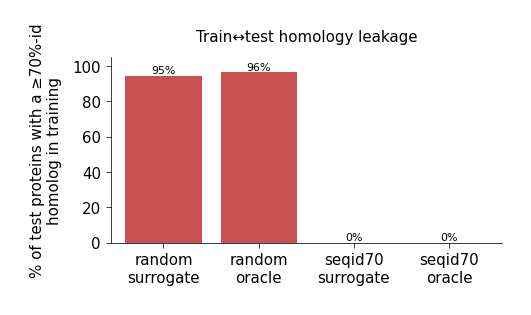

In [7]:
# bar chart of test-set leakage
fig,ax=plt.subplots(figsize=(7,4))
labels=["random\nsurrogate","random\noracle","seqid70\nsurrogate","seqid70\noracle"]
vals=[leak(RSr)["test"][2],leak(ROr)["test"][2],leak(Sr)["test"][2],leak(Or)["test"][2]]
cols=[apc_c.dragon,apc_c.dragon,apc_c.seaweed,apc_c.seaweed]
b=ax.bar(labels,vals,color=cols)
for r,v in zip(b,vals): ax.text(r.get_x()+r.get_width()/2,v+1,f"{v:.0f}%",ha="center",fontsize=11)
ax.set_ylabel("% of test proteins with a ≥70%-id\nhomolog in training"); ax.set_ylim(0,105)
ax.set_title("Train↔test homology leakage"); plt.tight_layout(); plt.show()


## 4. Where the split boundaries fall in peak space

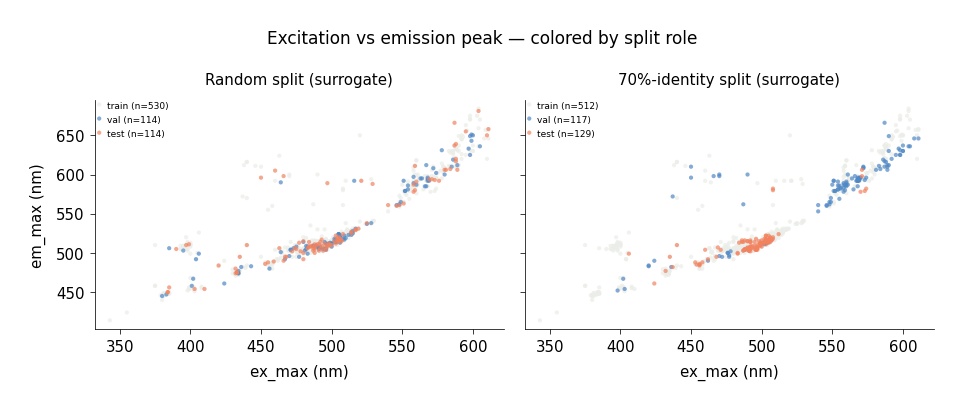

Note: in the 70%-identity split whole lineages move together, so test/val occupy
coherent regions of peak space rather than being sprinkled among the training points.


In [8]:
fig,ax=plt.subplots(1,2,figsize=(13,5.2),sharex=True,sharey=True)
palette={"train":apc_c.gray,"val":apc_c.aegean,"test":apc_c.amber}
for c,(title,role) in enumerate([("Random split (surrogate)",RSr),("70%-identity split (surrogate)",Sr)]):
    a=ax[c]
    for s in ("train","val","test"):
        idx=np.where(role==s)[0]
        a.scatter(peaks[idx,0],peaks[idx,1],s=18,alpha=0.7,color=palette[s],
                  label=f"{s} (n={len(idx)})",edgecolors="none")
    a.set_title(title); a.set_xlabel("ex_max (nm)"); a.legend(fontsize=9,loc="upper left")
ax[0].set_ylabel("em_max (nm)")
plt.suptitle("Excitation vs emission peak — colored by split role"); plt.tight_layout(); plt.show()
print("Note: in the 70%-identity split whole lineages move together, so test/val occupy\n"
      "coherent regions of peak space rather than being sprinkled among the training points.")


## Summary

- **57 clusters** at 70% identity; a handful of lineages dominate (largest ≈ 36% of the data).
- The **random** split leaks ~95% of its test proteins (a near-identical homolog sits in training);
  the **70%-identity** split leaks **0%** by construction, while keeping the coordinated dual
  structure (`S_test ⊆ O_train`, `O_test ⊆ S_train`, disjoint val).
- New artifacts written (no existing file touched): `seqid70_clusters.csv`,
  `dual_splits_seqid70.csv`.
- Next: `surrogate_oracle_peak_seqid70.ipynb` trains the surrogate/oracle on this split with the
  unchanged architectures/hyperparameters and compares peak-MAE against the random split.
